<a href="https://colab.research.google.com/github/ibtihalalf/Exercises1/blob/main/Week2/M3/m3_2_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)


A Figure is the entire canvas or window that holds everything (all plots, titles, etc.).

An Axes is a single plot inside the figure where data is actually drawn (it has the x-axis, y-axis, and the graph).


**2.** Name the three figure-level functions in `seaborn`.


displot() → creates distribution plots (like histograms or KDE) across a figure

jointplot() → shows the relationship between two variables along with their individual distributions

pairplot() → plots pairwise relationships between multiple variables in a dataset (a grid of plots)



**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


A Histogram shows how numerical data is distributed by grouping values into bins (ranges).

A Barplot compares values across categories, where each bar represents a category.

## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

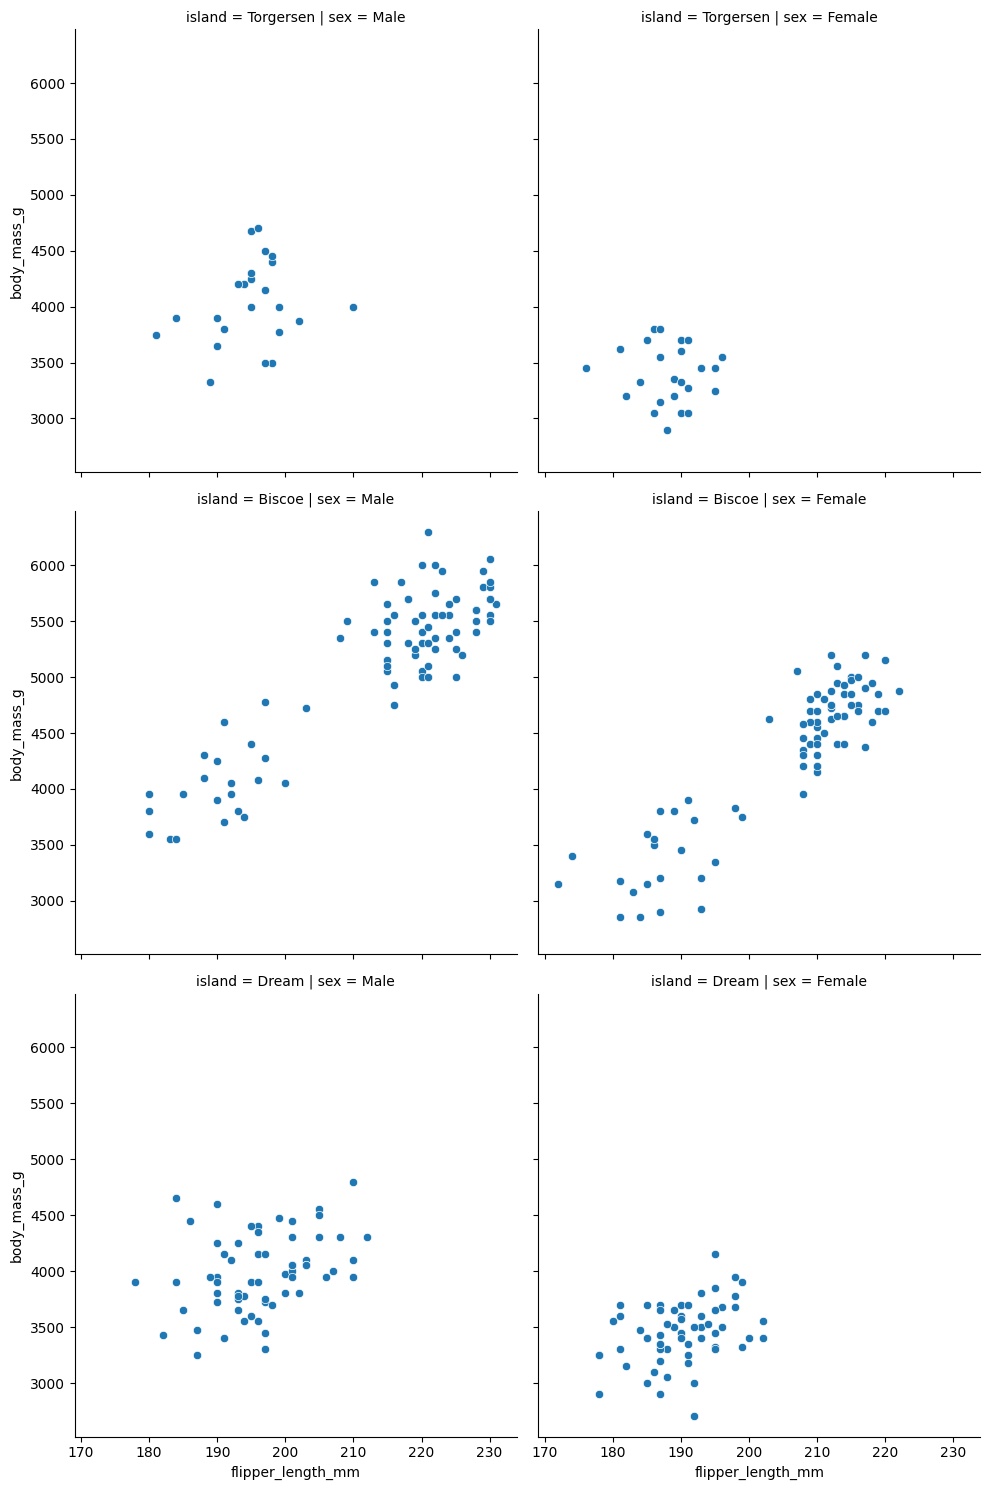

In [3]:
penguins = sns.load_dataset("penguins").dropna()

# Create figure-level plot with subplots
g = sns.relplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    col="sex",        # columns split by sex
    row="island",     # rows split by island
    kind="scatter"
)

plt.show()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`.
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

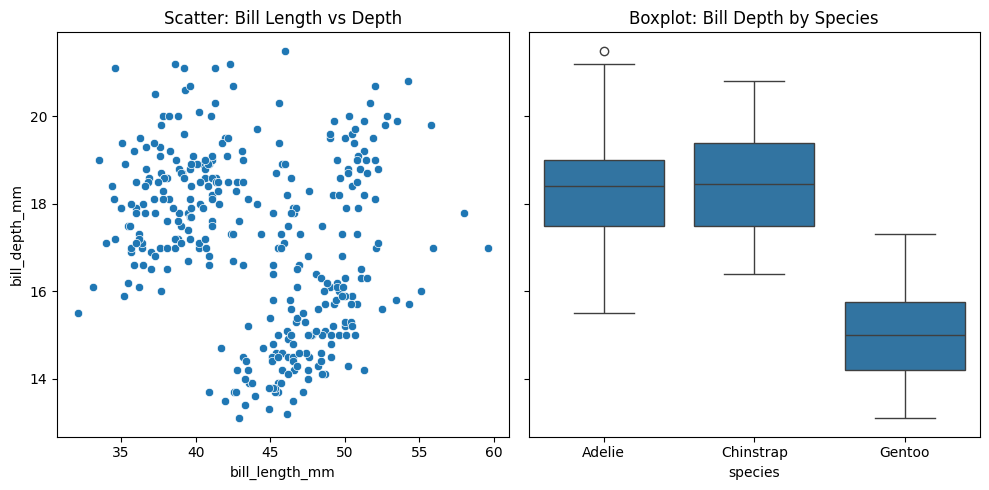

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# First subplot: scatterplot
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    ax=ax1
)
ax1.set_title("Scatter: Bill Length vs Depth")

# Second subplot: boxplot
sns.boxplot(
    data=penguins,
    x="species",
    y="bill_depth_mm",
    ax=ax2
)
ax2.set_title("Boxplot: Bill Depth by Species")

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

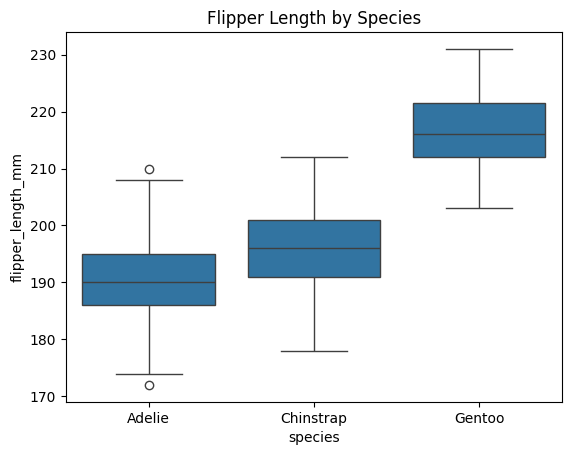

In [7]:
sns.boxplot(
    data=penguins,
    x="species",
    y="flipper_length_mm"
)

plt.title("Flipper Length by Species")
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



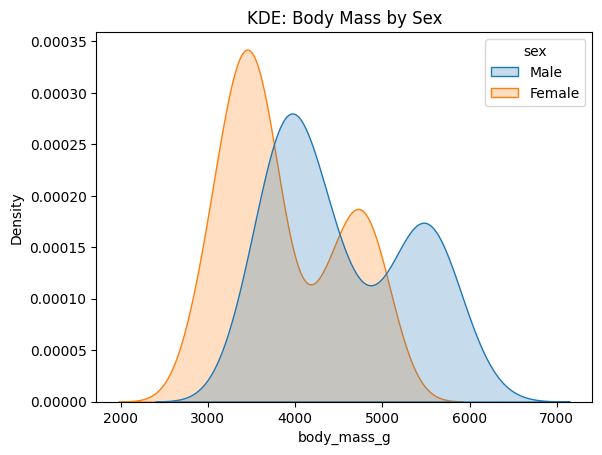

In [11]:
sns.kdeplot(
    data=penguins,
    x="body_mass_g",
    hue="sex",        # separate curves
    fill=True         # shaded areas
)

plt.title("KDE: Body Mass by Sex")
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



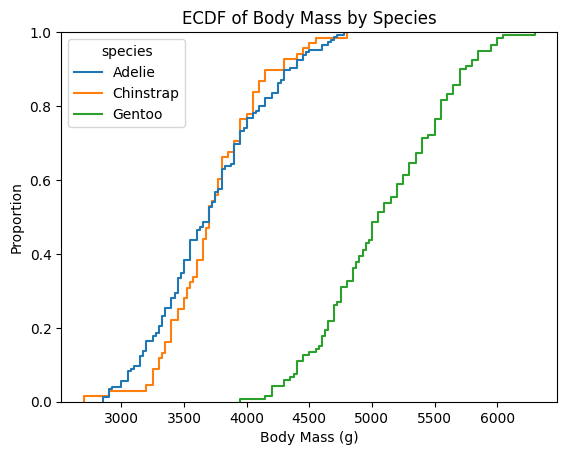

In [12]:
sns.ecdfplot(
    data=penguins,
    x="body_mass_g",
    hue="species"
)

plt.title("ECDF of Body Mass by Species")
plt.xlabel("Body Mass (g)")
plt.ylabel("Proportion")
plt.show()

Gentoo :They are generally heavier

Adelie : They are generally lighter

Chinstrap : Medium weight compared to the other two



**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



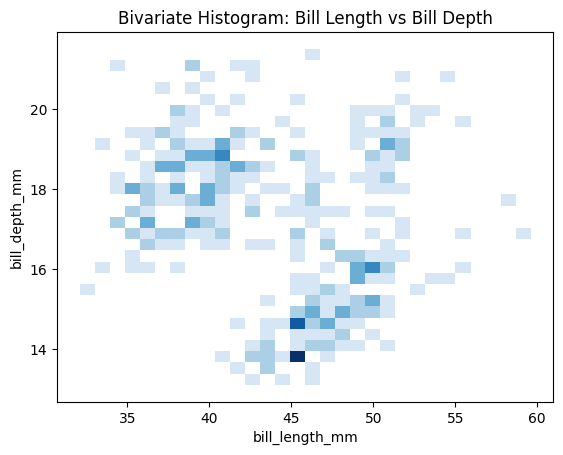

In [13]:
sns.histplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    bins=30,
    cmap="Blues"
)

plt.title("Bivariate Histogram: Bill Length vs Bill Depth")
plt.show()

The intensity (color) shows the number of data points (frequency) in each bin.

Darker color → more penguins fall in that range

Lighter color → fewer penguins

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

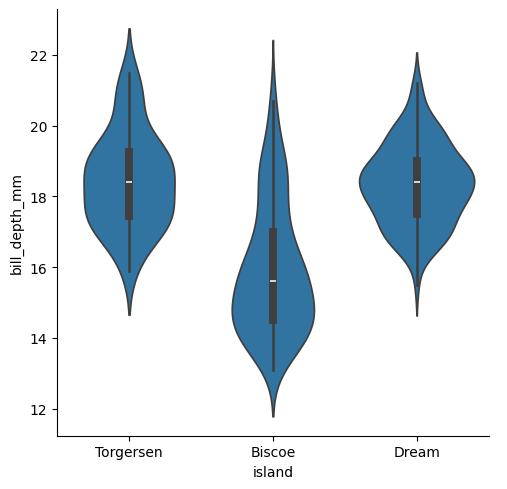

In [14]:
sns.catplot(
    data=penguins,
    x="island",
    y="bill_depth_mm",
    kind="violin"
)

plt.show()

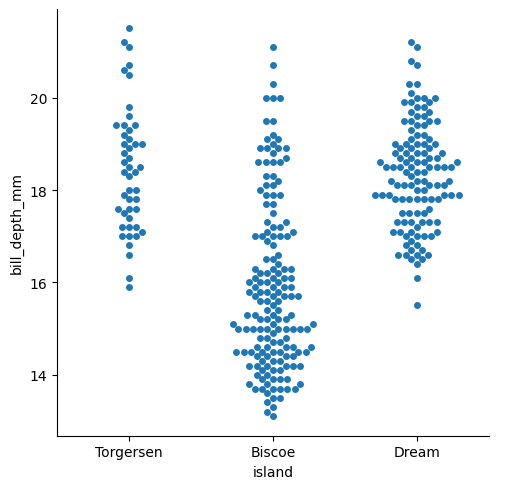

In [15]:
sns.catplot(
    data=penguins,
    x="island",
    y="bill_depth_mm",
    kind="swarm"
)

plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

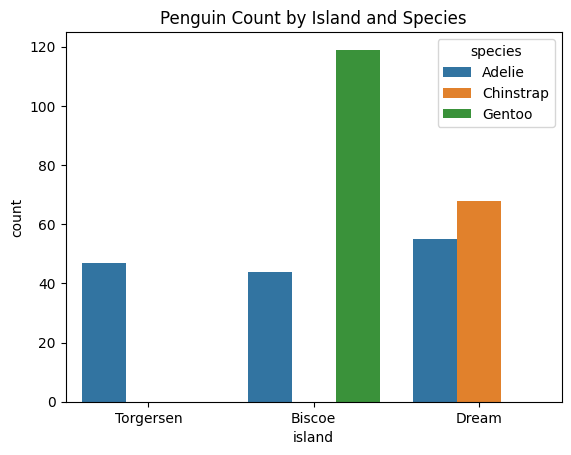

In [16]:
sns.countplot(
    data=penguins,
    x="island",
    hue="species"
)

plt.title("Penguin Count by Island and Species")
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

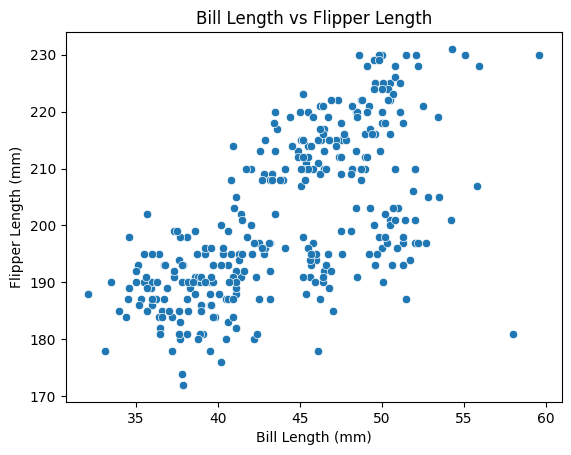

In [17]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="flipper_length_mm"
)

plt.title("Bill Length vs Flipper Length")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

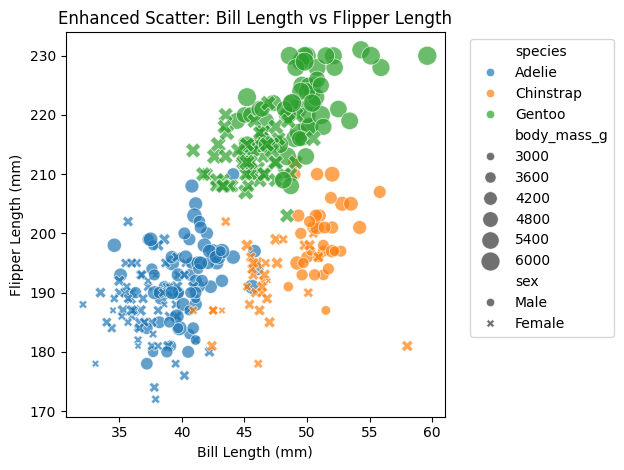

In [18]:
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",          # different colors
    style="sex",            # different marker shapes
    size="body_mass_g",     # point size based on mass
    sizes=(20, 200),        # control size range
    alpha=0.7               # slight transparency for readability
)

plt.title("Enhanced Scatter: Bill Length vs Flipper Length")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.tight_layout()
plt.show()